In [2]:
import numpy as np
from scipy.integrate import solve_ivp
from pyquaternion import Quaternion
from typing import Optional
from jaxtyping import Float, jaxtyped
from numpy.typing import NDArray
from beartype import beartype
import matplotlib.pyplot as plt
from functools import lru_cache
np.set_printoptions(precision=3, suppress=True, linewidth=200)

#@jaxtyped(typechecker=beartype)
def create_skew_matrix(
    input_vector: Float[NDArray, "3"]|Float[NDArray, "3 1"]|Float[NDArray, "1 3"],
) -> Float[NDArray, "3 3"]:
    
    input_vector = input_vector.reshape(3,)
    output_matrix = np.zeros((3, 3))
    output_matrix[1, 2], output_matrix[2, 1] = -input_vector[0], input_vector[0]
    output_matrix[2, 0], output_matrix[0, 2] = -input_vector[1], input_vector[1]
    output_matrix[1, 0], output_matrix[0, 1] = input_vector[2], -input_vector[2]

    return output_matrix

def spatial_cross_product(spatial_vel, transpose_and_negate = False): #TODO typehinting
    angular_vel, linear_vel = np.split(spatial_vel, 2)
    spatial_cross_vel = np.block([
        [create_skew_matrix(angular_vel), np.zeros((3,3))],
        [create_skew_matrix(linear_vel), create_skew_matrix(angular_vel)]
        ])
    if transpose_and_negate:
        spatial_cross_vel = -spatial_cross_vel.T

    return spatial_cross_vel

def get_quaternion_rate(quaternion, angular_velocity): #TODO typehinting
    """
    Input: quaternion vector first scalar last and angular velocity
    Output: quaternion rate

    This function takes unit quaternions and angular velocity to get the quaternion rate.
    """
    angular_velocity = angular_velocity.reshape(3,)
    ang_vel_tilde = create_skew_matrix(angular_velocity)
    quaternion_rate = 0.5 * np.block([
        [-ang_vel_tilde, angular_velocity.reshape(3,1)],
        [-angular_velocity, 0]
        ]) @ quaternion
    
    return quaternion_rate

def get_revolute_quaternion(angle, joint_axis):
    """
    Input: angle and joint axis of rotation
    Output: unit quaternion describing the attitude.
    
    This function is based on eq. B.12
    """
    
    if joint_axis == "x":
        n = np.array([1, 0, 0])
    elif joint_axis == "y":
        n = np.array([0, 1, 0])
    elif joint_axis == "z":
        n = np.array([0, 0, 1])
    else:
        print("unsupported")
        pass
        
    quaternion_vector = np.sin(angle/2)*n
    quaternion_scalar = np.array([np.cos(angle/2)])

    quaternion = np.concatenate((quaternion_vector, quaternion_scalar))

    return quaternion

def get_rotation_matrix(quarternion_scalar_last): #TODO typehinting
    """
    Input: quaternion with scalar part last
    Output: orthogonal rotation matrix 3x3
    """
    rotation_matrix = Quaternion(scalar=quarternion_scalar_last[-1], vector=quarternion_scalar_last[0:3]).rotation_matrix

    return rotation_matrix
    
def Equations_of_motion(spatial_inertia, forces, spatial_vel):
    """
    Input: spatial_inertia of a body, forces acting on the body and spatial velocity
    Output: generalized acceleration of the body

    Note that this is the implementation of lemma 2.3    
    """
    spatial_vel = spatial_vel.reshape(6,1)
    beta_b_dot = np.linalg.inv(spatial_inertia) @ (forces - spatial_cross_product(spatial_vel, True) @ spatial_inertia @ spatial_vel)
    
    return beta_b_dot.reshape(6,)

def get_gamma(time):
    """
    Input: Time as a float
    Output: List of np.arrays with acceleration values for each joint
    """
    def _acc_function(time):
        acceleration_value = np.sin(2*time*np.pi*1e-3)
    
        return acceleration_value

    A = _acc_function(time)
    #if necessary .reshape(3,1)
    gamma = [
             np.array([-2*A, 0, -2*A])*1e-6,
             np.array([-8*A])*1e-6,
             np.array([4*A])*1e-6,
             np.array([5*A, 0, 6*A])*1e-6
             ]
    
    return gamma
    
def state_space_differentiation(time, state, hinge_list=["s", "x", "x", "s"]): #TODO typehinting
    """
    Input: State 18x1 in assignment 2, spatial_inertia and forces
    Output: State derivative 18x1 in assignment 2
    """
    def _diff_theta(theta, beta, gamma, hinge_list):
        """
        Handles spherical hinges and revolute hinges as suggested in the assignment
        """
        theta_dot = np.empty_like(theta)
        beta_dot = np.empty_like(beta)
        theta_count = 0
        beta_count = 0

        for index, hinge in enumerate(hinge_list):
            if hinge == "s":
                theta_normalized = theta[theta_count:theta_count+4] / np.linalg.norm(theta[theta_count:theta_count+4])
                theta_dot[theta_count:theta_count+4] = get_quaternion_rate(theta_normalized, beta[beta_count:beta_count+3])
                beta_dot[beta_count:beta_count+3] = gamma[index]
                
                theta_count += 4
                beta_count += 3
            elif hinge in {"x", "y", "z"}:
                theta_dot[theta_count] = beta[beta_count]
                beta_dot[beta_count] = gamma[index][0]

                theta_count += 1
                beta_count += 1
            else:
                print(f"Unsupported hingetype: {hinge}")
                pass

        return theta_dot, beta_dot

    gamma = get_gamma(time)
    theta = state[0:10].copy()
    beta = state[10:18].copy()

    theta_dot, beta_dot = _diff_theta(theta, beta, gamma, hinge_list)
    state_diff = np.concatenate((theta_dot, beta_dot))

    return state_diff

def scatter_function(theta, beta, gamma, hinge_distances, hinge_list, base_movement=np.zeros((12,1))):
    """
    Input: orientations, velocities, accelerations and hinge distances / list
    Output: spatial orientations, rotations, velocities and accelerations
    """
    
    parent_velocity = base_movement[:6].reshape(6,1)
    parent_acceleration = base_movement[6:].reshape(6,1)
    theta_count=len(theta)
    beta_count=len(beta)


    spatial_orientations = np.zeros((len(hinge_list)*4))
    spatial_rotations = np.zeros((len(hinge_list), 3, 3))
    spatial_velocities = np.concatenate((parent_velocity, np.zeros((len(hinge_list)*6,1))))
    spatial_accelerations = np.zeros_like(spatial_velocities)
    
    #scatterloop
    for index, hinge in zip(range(len(hinge_list)-1, -1, -1), reversed(hinge_list)):
        hinge_map_transposed = get_hinge_map_transposed(hinge)

        if hinge == "s":
            theta_quaternion = theta[theta_count-4:theta_count] / np.linalg.norm(theta[theta_count-4:theta_count])
            rotation_matrix = get_rotation_matrix(theta_quaternion)
            spatial_orientations[index*4:(index+1)*4] = theta_quaternion
            spatial_rotations[index, :, :] = rotation_matrix

            delta_v = hinge_map_transposed @ beta[beta_count-3:beta_count].reshape(3,1)
            delta_a = hinge_map_transposed @ gamma[index][0:3].reshape(3,1)

            theta_count -= 4
            beta_count -= 3
        elif hinge in {"x", "y", "z"}:
            theta_quaternion = get_revolute_quaternion(theta[theta_count-1], hinge)
            theta_quaternion = theta_quaternion / np.linalg.norm(theta_quaternion)
            rotation_matrix = get_rotation_matrix(theta_quaternion)
            spatial_orientations[index*4:(index+1)*4] = theta_quaternion
            spatial_rotations[index, :, :] = rotation_matrix

            delta_v = hinge_map_transposed @ beta[beta_count-1].reshape(1,1)
            delta_a = hinge_map_transposed @ gamma[index][0].reshape(1,1)

            theta_count -= 1
            beta_count -= 1
        else:
            print(f"Unsupported hingetype: {hinge}")
            pass

        #calculate velocity
        phi_transposed = create_phi(hinge_distances[index,:], rotation_matrix, True)
        parent_velocity = phi_transposed @ parent_velocity + delta_v
        parent_acceleration = phi_transposed @ parent_acceleration + delta_a + spatial_cross_product(parent_velocity) @ delta_v

        spatial_velocities[(index+1)*6:(index+2)*6] = parent_velocity
        spatial_accelerations[(index+1)*6:(index+2)*6] = parent_acceleration



    return spatial_orientations, spatial_rotations, spatial_velocities, spatial_accelerations

def gather_function(rotations, velocities, accelerations, spatial_inertias, hinge_distances, hinge_list, tip_wrench=np.zeros((6))):
    """
    Input: rotations, velocities, accelerations, spatial inertias and hinge distances / list
    Output: spatial forces for each body
    """
    
    child_force = tip_wrench.reshape(6,1)

    spatial_forces = np.concatenate((child_force, np.zeros((len(hinge_list)*6,1))))
    
    #gatherloop
    for index, hinge in enumerate(hinge_list):

        phi = create_phi(hinge_distances[index,:], rotations[index, :, :], False)
        child_force = phi @ (child_force + spatial_inertias[index, :, :] @ accelerations[(index+1)*6:(index+2)*6] + \
                             spatial_cross_product(velocities[(index+1)*6:(index+2)*6], True) @ (spatial_inertias[index,:,:] @ velocities[(index+1)*6:(index+2)*6])
                             )
        
        spatial_forces[(index+1)*6:(index+2)*6] = child_force

    return spatial_forces
    
#@jaxtyped(typechecker=beartype)
def create_phi(position: Optional[Float[NDArray, "3 1"]|Float[NDArray, "3"]|Float[NDArray, "1 3"]]=None, 
               rotation: Optional[Float[NDArray, "3 3"]]=None, transpose=False) -> Float[NDArray, "6 6"]:
    
    def _create_phi_rotation(rotation_matrix: Float[NDArray, "3 3"]) -> Float[NDArray, "6 6"]:
        phi_rotation = np.kron(np.eye(2), rotation_matrix)
        return phi_rotation

    phi = np.eye(6)
    if position is not None:
        phi[0:3,3:6] = create_skew_matrix(position)
    if rotation is not None:
        phi = phi @ _create_phi_rotation(rotation)
    if transpose:
        phi = phi.T

    return phi

@lru_cache(None)
def get_hinge_map_transposed(hingetype="s", transposed=True):
    """
    Input: Hingetype and transpose option
    Output: Hingemap transposed unless option chosen
    """
    
    if hingetype == "s":
        hingemap = np.concatenate((np.eye(3), np.zeros((3,3))))
    elif hingetype == "x":
        hingemap = np.concatenate((np.ones((1,1)), np.zeros((5,1))))
    elif hingetype == "y":
        hingemap = np.concatenate((np.zeros((1,1)), np.ones((1,1)), np.zeros((4,1))))
    elif hingetype == "z":
        hingemap = np.concatenate((np.zeros((2,1)), np.ones((1,1)), np.zeros((3,1))))
    else:
        print(f"unsupported hingetype. hingetype input was {hingetype}")
        return
        
    if not transposed:
        hingemap = hingemap.T
    
    return hingemap

def get_system_spatial_inertia(mass_vec, inertia_tensor, cg_matrix):
    """
    Input: Mass vector, Inertia tensor C and matrix to C
    Output: Spatial inertia matrix

    Wraps _get_spatial_inertia to output system wide tensor of spatial inertias    
    """
    def _get_spatial_inertia(mass, inertia, cg_vector=np.zeros((3,1))):
        """
        Input: Mass, Inertia matrix C and vector to C
        Output: Spatial inertia matrix

        Get spatial inertia matrix at an arbitrary point using inertia at C, cg and mass
        """
        cg_skew = create_skew_matrix(cg_vector)
        spatial_inertia = np.block([[inertia - mass * cg_skew @ cg_skew, mass * cg_skew],
                                    [-mass * cg_skew, mass * np.eye(3)]])
        return spatial_inertia    
    
    spatial_inertias = np.empty((mass_vec.shape[0], 6, 6))

    for index, mass in enumerate(mass_vec):
        spatial_inertias[index,:,:] = _get_spatial_inertia(mass, inertia_tensor[index,:,:], cg_matrix[index, :])

    return spatial_inertias



In [3]:
#CG_positions
l_1_cg = np.array([0, 0, 0.7])
l_2_cg = np.array([0, 0, 2.5])
l_5_cg = np.zeros((3,), dtype=float)

l_cg = np.array([l_1_cg, l_2_cg, l_2_cg, l_2_cg], dtype=float)

#Length to hinge ok+ to ok
l_2_h = np.array([0, 0, 5])
l_5_h = np.array([12, 4, 2])

l_h = np.array([l_2_h, l_2_h, l_2_h, l_5_h], dtype=float)

#individual masses
mass_vector = np.array([14_520, 400, 400, 400], dtype=float)

#Inertias
inertia_2_c = np.diag([834, 834, 0.72])
inertia_1_c = np.diag([1.01e+4, 1.51e+4, 0.331e+4])

inertia_tensor = np.array([inertia_1_c, inertia_2_c, inertia_2_c, inertia_2_c], dtype=float)

#Spatial inertias
spatial_inertias = get_system_spatial_inertia(mass_vector, inertia_tensor, l_cg)

#hinges
hinge_list=["s", "x", "x", "s"]

#Initial state
initial_state = np.array([
    0, 0, 0, 1,
    np.pi/4,
    np.pi/4,
    0, 0, 0, 1,
    0, 0, 0, 0,
    0, 0, 0, 0,
    ])

#Simulation settings
t_start = 0
t_end = 1000
t_eval = np.linspace(t_start, t_end, 1000)

#solve for timesteps
timeseries_solution = solve_ivp(
    state_space_differentiation, 
    (t_start, t_end), 
    initial_state, 
    t_eval=t_eval,
    args=(hinge_list,), 
    rtol=1e-9,
    atol=1e-9,)

#incrementing in time and calling scatter-gather loops:
forces = np.empty((30, len(timeseries_solution.t)))
for index, state in enumerate(timeseries_solution.y.T):
    theta = state[0:10]
    beta = state[10:18]
    gamma = get_gamma(timeseries_solution.t[index])
    _, rot, vel, acc = scatter_function(theta, beta, gamma, l_h, hinge_list)
    forces[:, index] = gather_function(rot, vel, acc, spatial_inertias, l_h, hinge_list).reshape(-1)


In [11]:
import pandas as pd
dataframe = pd.DataFrame(forces.T[:,::-1])
dataframe.to_csv("q2_generalized_forces.csv")


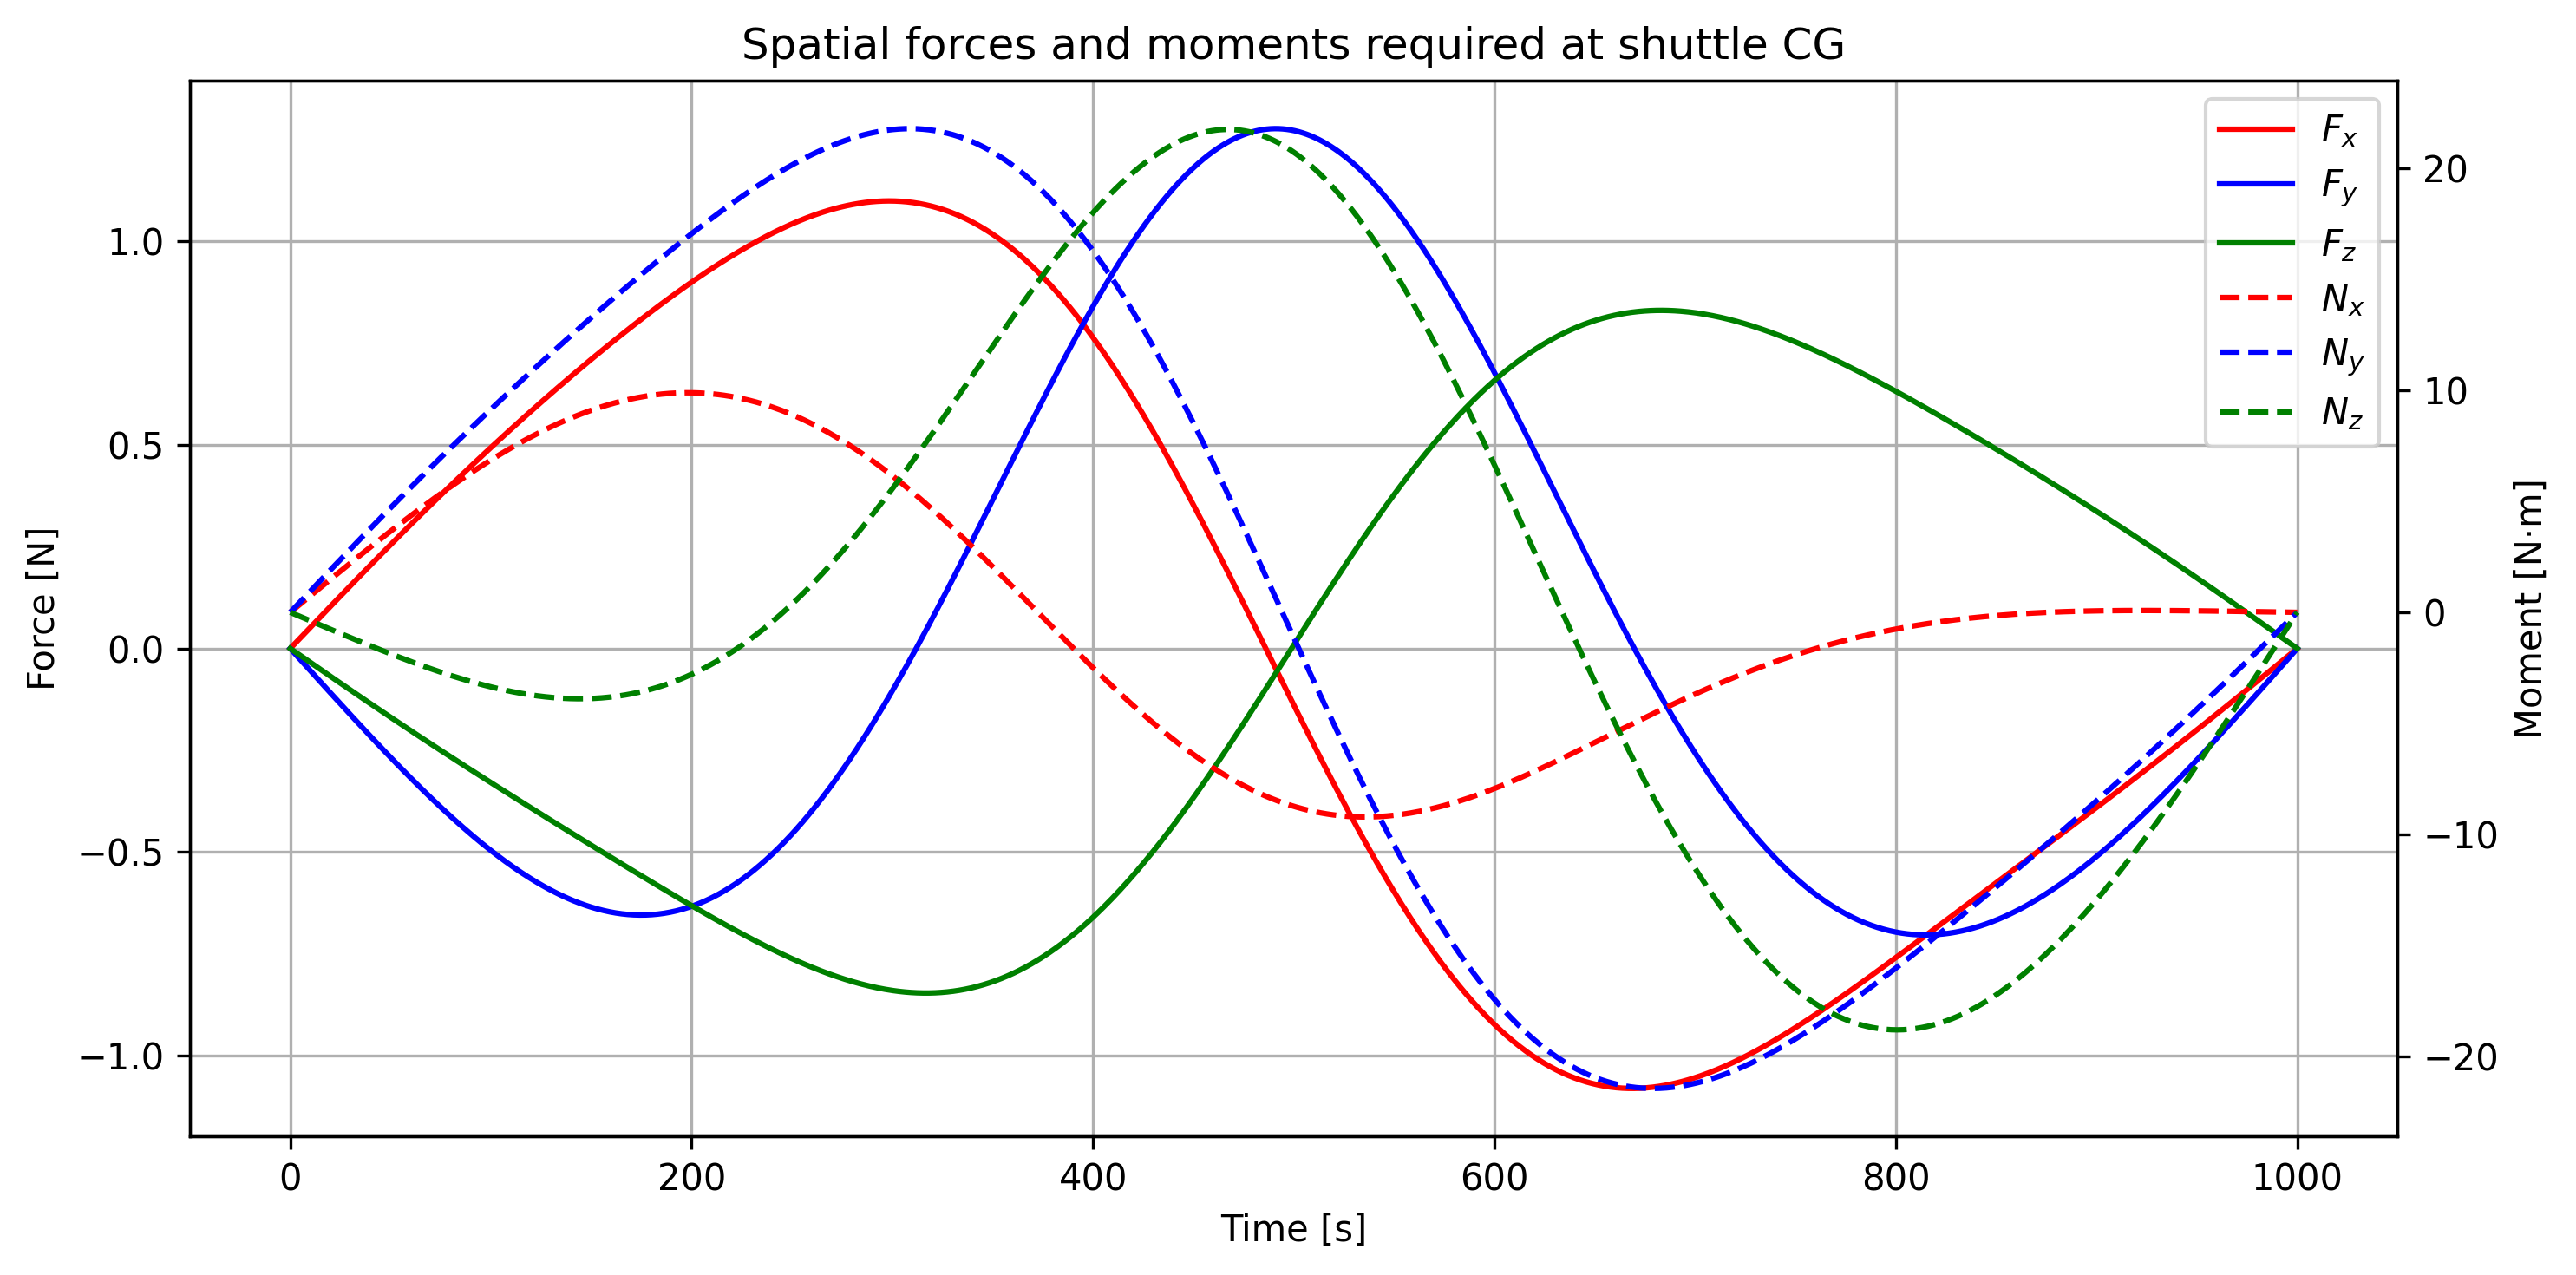

In [5]:
#This cell has been generated with chatgpt. The code in the rest of the cells are handwritten.

t = timeseries_solution.t
Fstack = forces
wrench_CG_arm_on_shuttle = forces[-6:, :]

Mx, My, Mz = wrench_CG_arm_on_shuttle[0, :], wrench_CG_arm_on_shuttle[1, :], wrench_CG_arm_on_shuttle[2, :]
Fx, Fy, Fz = wrench_CG_arm_on_shuttle[3, :], wrench_CG_arm_on_shuttle[4, :], wrench_CG_arm_on_shuttle[5, :]

fig, axF = plt.subplots(figsize=(10,5))
fig.set_dpi(300)
# Forces (solid)
l1, = axF.plot(t, Fx, "r",  label=r"$F_x$")
l2, = axF.plot(t, Fy, "b",  label=r"$F_y$")
l3, = axF.plot(t, Fz, "g",  label=r"$F_z$")
axF.set_xlabel("Time [s]")
axF.set_ylabel("Force [N]")
axF.grid(True)

# Moments (dashed, same colors)
axM = axF.twinx()
m1, = axM.plot(t, Mx, "r--", label=r"$N_x$")
m2, = axM.plot(t, My, "b--", label=r"$N_y$")
m3, = axM.plot(t, Mz, "g--", label=r"$N_z$")
axM.set_ylabel("Moment [N·m]")

axF.legend([l1,l2,l3,m1,m2,m3],
           [r"$F_x$",r"$F_y$",r"$F_z$",r"$N_x$",r"$N_y$",r"$N_z$"],
           loc="upper right")

plt.title("Spatial forces and moments required at shuttle CG")
plt.tight_layout()
plt.savefig("elsearticle/images/wrench_result.png")
plt.show()